# Tarea en Python: Teorema de Bayes y Red Bayesiana

## Diagnóstico de un estudiante: ¿aprobará o desaprobará?

Se estimara la probabilidad de aprobación de un estudiante a partir de sus horas de estudio, asistencia y nota del examen.

### Variables
- **HorasEstudio:** Pocas / Muchas
- **Asistencia:** Baja / Alta
- **NotaExamen:** Baja / Alta
- **Aprobacion:** Desaprueba / Aprueba

### Estructura
`HorasEstudio → Asistencia → NotaExamen → Aprobacion`


In [29]:
!pip install pgmpy

In [30]:
#liberia de redes bayesianas
#crear la red bayesiana
from pgmpy.models import DiscreteBayesianNetwork
#crear una tabla de probabilidades condicionales
from pgmpy.factors.discrete import TabularCPD
#realizar interfferencia en la red bayesiana
from pgmpy.inference import VariableElimination

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [31]:
# 1. Crear la estructura de la red bayesiana

model = DiscreteBayesianNetwork([
    ("HorasEstudio", "Asistencia"),
    ("Asistencia", "NotaExamen"),
    ("NotaExamen", "Aprobacion")
])

print("Estructura de la red:")
print(model.edges())


Estructura de la red:
[('HorasEstudio', 'Asistencia'), ('Asistencia', 'NotaExamen'), ('NotaExamen', 'Aprobacion')]


In [32]:
# 2. CPD de HorasEstudio
# P(Pocas)=0.60 y P(Muchas)=0.40

cpd_horas = TabularCPD(
    variable="HorasEstudio",
    variable_card=2,
    values=[[0.60], [0.40]],
    state_names={"HorasEstudio": ["Pocas", "Muchas"]}
)

cpd_horas


<TabularCPD representing P(HorasEstudio:2) at 0x7a09fdad4850>

In [33]:
# 3. CPD de Asistencia | HorasEstudio
# P(Baja|Pocas)=0.80, P(Alta|Pocas)=0.20
# P(Baja|Muchas)=0.30, P(Alta|Muchas)=0.70

cpd_asistencia = TabularCPD(
    variable="Asistencia",
    variable_card=2,
    values=[
        [0.80, 0.30],
        [0.20, 0.70]
    ],
    evidence=["HorasEstudio"],
    evidence_card=[2],
    state_names={
        "Asistencia": ["Baja", "Alta"],
        "HorasEstudio": ["Pocas", "Muchas"]
    }
)

cpd_asistencia


<TabularCPD representing P(Asistencia:2 | HorasEstudio:2) at 0x7a09be1e8d50>

In [34]:
# 4. CPD de NotaExamen | Asistencia
# P(Baja|Baja)=0.70, P(Alta|Baja)=0.30
# P(Baja|Alta)=0.20, P(Alta|Alta)=0.80

cpd_nota = TabularCPD(
    variable="NotaExamen",
    variable_card=2,
    values=[
        [0.70, 0.20],
        [0.30, 0.80]
    ],
    evidence=["Asistencia"],
    evidence_card=[2],
    state_names={
        "NotaExamen": ["Baja", "Alta"],
        "Asistencia": ["Baja", "Alta"]
    }
)

cpd_nota


<TabularCPD representing P(NotaExamen:2 | Asistencia:2) at 0x7a09ab6a27b0>

In [35]:
# 5. CPD de Aprobacion | NotaExamen
# P(Desaprueba|Baja)=0.95, P(Aprueba|Baja)=0.05
# P(Desaprueba|Alta)=0.10, P(Aprueba|Alta)=0.90

cpd_aprobacion = TabularCPD(
    variable="Aprobacion",
    variable_card=2,
    values=[
        [0.95, 0.10],
        [0.05, 0.90]
    ],
    evidence=["NotaExamen"],
    evidence_card=[2],
    state_names={
        "Aprobacion": ["Desaprueba", "Aprueba"],
        "NotaExamen": ["Baja", "Alta"]
    }
)

cpd_aprobacion


<TabularCPD representing P(Aprobacion:2 | NotaExamen:2) at 0x7a09ab6a32f0>

In [36]:
# 6. Agregar las CPD y verificar el modelo

model.add_cpds(
    cpd_horas,
    cpd_asistencia,
    cpd_nota,
    cpd_aprobacion
)

print("¿El modelo es válido?:", model.check_model())


¿El modelo es válido?: True


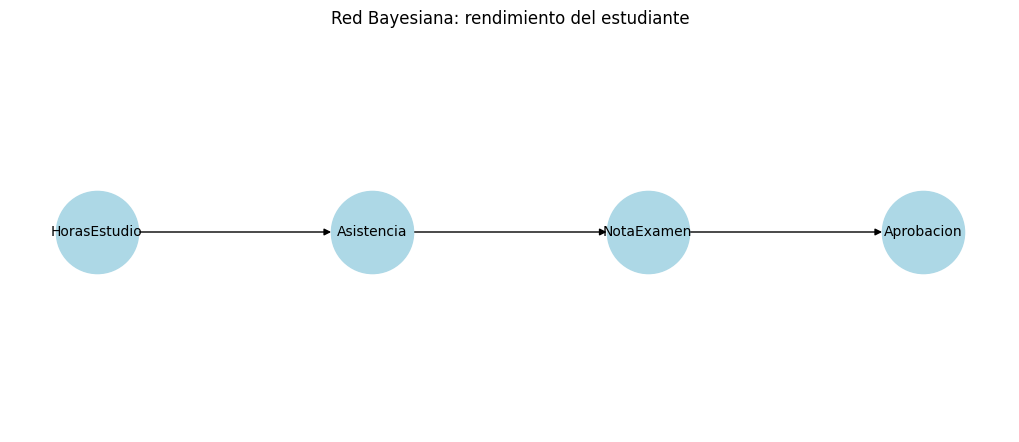

In [37]:
# 7. Visualizar la red

import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

pos = {
    "HorasEstudio": (0, 0),
    "Asistencia": (1, 0),
    "NotaExamen": (2, 0),
    "Aprobacion": (3, 0)
}

nx.draw(
    model,
    pos,
    with_labels=True,
    node_size=3500,
    node_color="lightblue",
    font_size=10,
    arrows=True
)

plt.title("Red Bayesiana: rendimiento del estudiante")
plt.axis("off")
plt.show()


## 8. Consulta principal

**Pregunta:** ¿Cuál es la probabilidad de que un estudiante apruebe si estudia muchas horas y tiene asistencia alta?

La inferencia considera que todavía existe incertidumbre sobre la nota del examen.


In [38]:
# 8. P(Aprobacion | HorasEstudio=Muchas, Asistencia=Alta)

inferencia = VariableElimination(model)

resultado = inferencia.query(
    variables=["Aprobacion"],
    evidence={
        "HorasEstudio": "Muchas",
        "Asistencia": "Alta"
    }
)

print("Probabilidad de aprobación:")
print(resultado)
print(
    f"\nP(Aprueba | Muchas horas, Alta asistencia) "
    f"= {resultado.values[1]:.2%}"
)


Probabilidad de aprobación:
+------------------------+-------------------+
| Aprobacion             |   phi(Aprobacion) |
+========================+===================+
| Aprobacion(Desaprueba) |            0.2700 |
+------------------------+-------------------+
| Aprobacion(Aprueba)    |            0.7300 |
+------------------------+-------------------+

P(Aprueba | Muchas horas, Alta asistencia) = 73.00%


### Interpretación de la consulta principal

Con asistencia alta, la probabilidad de obtener una nota alta es 80%. Una nota alta tiene 90% de probabilidad de terminar en aprobación.

Por probabilidad total:

`P(Aprueba | Alta asistencia) = (0.90)(0.80) + (0.05)(0.20)`

`= 0.73 = 73%`

Por eso, para el caso **muchas horas + asistencia alta**, la probabilidad de aprobar es **73%**.


In [39]:
# 9. Probabilidad de aprobación sin evidencia

resultado_prior = inferencia.query(
    variables=["Aprobacion"]
)

print("Probabilidad de aprobación sin evidencia:")
print(resultado_prior)
print(f"\nP(Aprueba) = {resultado_prior.values[1]:.2%}")


Probabilidad de aprobación sin evidencia:
+------------------------+-------------------+
| Aprobacion             |   phi(Aprobacion) |
+========================+===================+
| Aprobacion(Desaprueba) |            0.5250 |
+------------------------+-------------------+
| Aprobacion(Aprueba)    |            0.4750 |
+------------------------+-------------------+

P(Aprueba) = 47.50%


In [40]:
# 10. Caso desfavorable:
# ¿Qué pasa si estudia pocas horas y tiene asistencia baja?

resultado_bajo = inferencia.query(
    variables=["Aprobacion"],
    evidence={
        "HorasEstudio": "Pocas",
        "Asistencia": "Baja"
    }
)

print("Si estudia pocas horas y tiene asistencia baja:")
print(resultado_bajo)
print(
    f"\nP(Aprueba | Pocas horas, Baja asistencia) "
    f"= {resultado_bajo.values[1]:.2%}"
)


Si estudia pocas horas y tiene asistencia baja:
+------------------------+-------------------+
| Aprobacion             |   phi(Aprobacion) |
+========================+===================+
| Aprobacion(Desaprueba) |            0.6950 |
+------------------------+-------------------+
| Aprobacion(Aprueba)    |            0.3050 |
+------------------------+-------------------+

P(Aprueba | Pocas horas, Baja asistencia) = 30.50%


## 11. Aplicación del Teorema de Bayes


**¿Cuál es la probabilidad de que haya estudiado muchas horas si sabemos que obtuvo una nota alta?**

El modelo obtiene:

- `P(NotaExamen=Alta) = 0.31`
- `P(HorasEstudio=Muchas y NotaExamen=Alta) = 0.224`

Entonces:

`P(Muchas horas | Nota alta) = 0.224 / 0.31`

`≈ 0.7226 = 72.26%`


In [41]:
# 12. Verificación de Bayes mediante inferencia

resultado_bayes = inferencia.query(
    variables=["HorasEstudio"],
    evidence={"NotaExamen": "Alta"}
)

print("P(HorasEstudio | NotaExamen=Alta):")
print(resultado_bayes)
print(
    f"\nP(Muchas horas | Nota alta) "
    f"= {resultado_bayes.values[1]:.4f} "
    f"= {resultado_bayes.values[1]*100:.2f}%"
)


P(HorasEstudio | NotaExamen=Alta):
+----------------------+---------------------+
| HorasEstudio         |   phi(HorasEstudio) |
+======================+=====================+
| HorasEstudio(Pocas)  |              0.4800 |
+----------------------+---------------------+
| HorasEstudio(Muchas) |              0.5200 |
+----------------------+---------------------+

P(Muchas horas | Nota alta) = 0.5200 = 52.00%


## 13. Conclusión

La red bayesiana combina las probabilidades de **horas de estudio, asistencia y nota del examen** para estimar la aprobación.

- Sin evidencia, la probabilidad de aprobar es **47.50%**.
- Con muchas horas de estudio y asistencia alta, la probabilidad de aprobar es **73%**.
- Con pocas horas y asistencia baja, la probabilidad de aprobar es **30.50%**.
- También podemos razonar en sentido inverso: una nota alta hace más probable que el estudiante haya estudiado muchas horas.

Según las probabilidades planteadas en el ejercicio, estudiar más y mantener una asistencia alta se relaciona con una mayor probabilidad de obtener una nota alta y aprobar.
